# Friction Survival: Where the Edge Dies

**Docker image**: `ml4t`

This notebook cross-cuts the case studies by **failure mode**: gross-to-net
Sharpe degradation, breakeven cost thresholds, cadence-frequency vulnerability,
and cost-model realism caveats. Ch18 establishes the cost taxonomy and the
per-asset-class machinery; this notebook reads the resulting Ch18 cost-sweep
backtests directly out of each case study's registry and asks which
strategies survive the friction of real trading.

**Learning Objectives**:
- Quantify each strategy's sensitivity to per-leg friction on a common scale
- Identify breakeven cost thresholds per rebalance cadence
- Recognize when a generic basis-point sweep is the wrong cost model
  (single-name options, intraday equities)

**Book Reference**: Chapter 20, Section 20.6 (Trading Realism)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.
Each case study's registry must contain Ch18 `cost_sensitivity`-stage backtests.

In [1]:
"""Ch20 Friction Survival — cross-case-study cost-sweep analysis from registry."""

import json

import matplotlib.pyplot as plt
import polars as pl
from IPython.display import Markdown, display
from matplotlib.patches import Patch

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    SHORT_NAMES,
    load_carrier_cost_curves,
)
from utils.paths import get_chapter_dir
from utils.style import show_with_alt

pl.Config.set_tbl_rows(20)

polars.config.Config

In [2]:
# 0 = all
MAX_CASE_STUDIES = 0

In [3]:
CS_LIST = CASE_STUDY_IDS[:MAX_CASE_STUDIES] if MAX_CASE_STUDIES else CASE_STUDY_IDS

## Load Cost Sweep Results from Registry

Ch18 backtests vary commission + slippage across a grid of cost levels
while holding the signal and allocation constant. We read the sweep for
each case study's **release configuration** -- the one declared across
the signal, allocation, and risk-overlay stages --
so the breakeven measured here is the cost survival of the strategy the
chapter actually deploys, not of whichever allocator happened to be best
at zero cost.

A case study can hold cost-sensitivity backtests and still draw no curve here, because
the sweep has to sit on the carrier's own training lineage *and* run the carrier's own
strategy. The loader reports which check dropped each one, printed below the load, so an
absence from the charts can be read rather than guessed at.

In [4]:
loaded = load_carrier_cost_curves(CS_LIST)
costs_df = loaded.curves
_exclusions = loaded.exclusion_lines()

if costs_df.is_empty():
    # The reasons go into the refusal rather than after it. Every case study being excluded is
    # the state that most needs them - a clean clone with no registries reaches it - and the
    # loader has already established each one.
    msg = "No Ch18 cost-sensitivity backtests found for any deployed carrier"
    raise RuntimeError("\n".join([msg, *_exclusions]) if _exclusions else msg)

n_cs = costs_df["case_study"].n_unique()
print(f"Loaded {len(costs_df)} carrier cost-sweep entries across {n_cs} case studies")
for _line in _exclusions:
    print(_line)
costs_df.head(5)

Loaded 67 carrier cost-sweep entries across 6 case studies
  no curve for ETFs: no cost sweep on the carrier's lineage - 0 validation cost_sensitivity backtests on training_hash=ab5300c0cda4, carrier linear/ols on fwd_ret_5d
  no curve for NQ100: cost sweep is on a different strategy - 24 cost_sensitivity backtests on training_hash=7a0c26a08db7, none matching the carrier's strategy signature (slot_persistent_signal_exit)
  no curve for SP500 Options: cost sweep is on a different strategy - 8 cost_sensitivity backtests on training_hash=e698033183d9, none matching the carrier's strategy signature (equal_weight_top_k + score_weighted)


case_study,label,allocator,cost_bps,sharpe,total_return,max_drawdown,display_name,cadence
str,str,str,f64,f64,f64,f64,str,str
"""cme_futures""","""fwd_ret_21d""","""unknown""",0.0,1.166293,0.945418,-0.194881,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_21d""","""unknown""",1.0,1.151537,0.930125,-0.197652,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_21d""","""unknown""",2.0,1.1364,0.911526,-0.196845,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_21d""","""unknown""",3.0,1.125218,0.898673,-0.198984,"""CME Futures""","""monthly"""
"""cme_futures""","""fwd_ret_21d""","""unknown""",5.0,1.087329,0.85497,-0.202183,"""CME Futures""","""monthly"""


Assumed per-leg cost and rebalance cadence both come from each case study's
`setup.yaml`, read back through the Ch20 artifacts that `01_aggregate_synthesis`
writes, rather than being typed into this notebook.

`setup.yaml` records a specific cadence such as `monthly_month_end` or
`daily_ny_close`. The charts group by period, taken from the leading word, and
anything unrecognised is grouped as unspecified rather than given a default.
The turnover multipliers attached to each period say how often a book of that
cadence is assumed to turn over relative to a daily one. They are an
assumption, not turnover measured from the backtests.

## Gross-to-Net Sharpe Degradation

For each case study we compare the zero-cost (gross) Sharpe with the Sharpe at
the cost that case study actually assumes, which comes from its `setup.yaml`
by way of `overview.parquet`. The assumed cost rarely falls on a grid point, so
the net Sharpe is interpolated linearly between the two grid points that
bracket it, and the bracketing points are reported alongside.


In [5]:
gross_df = costs_df.filter(pl.col("cost_bps") == 0)
net_df = costs_df.filter(pl.col("cost_bps") > 0)

# One allocator per case study (the selected configuration's); this selects it.
best_alloc = (
    gross_df.sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", "allocator")
)

In [6]:
_overview = pl.read_parquet(get_chapter_dir(20) / "output" / "overview.parquet")
ASSUMED_COST_BPS = dict(_overview.select("cs_id", "cost_bps").iter_rows())
_synthesis = json.loads((get_chapter_dir(20) / "output" / "all_synthesis.json").read_text())
CADENCE_BY_CS = {
    cs: (data["meta"].get("cadence") or "unspecified") for cs, data in _synthesis.items()
}

CADENCE_PERIODS = ("15min", "hourly", "8_hour", "daily", "weekly", "monthly")
TURNOVER_MULTIPLIER = {
    "15min": 26.0,
    "hourly": 6.5,
    "8_hour": 3.0,
    "daily": 1.0,
    "weekly": 1.0 / 5,
    "monthly": 1.0 / 21,
}


def _cadence_period(cadence: str) -> str:
    for period in CADENCE_PERIODS:
        if cadence.startswith(period):
            return period
    return "unspecified"


def _sharpe_at(curve: pl.DataFrame, cost_bps: float) -> tuple[float, float, float]:
    """Sharpe at `cost_bps`, linearly interpolated on the sweep grid.

    Returns the interpolated Sharpe and the two grid costs it sits between. A
    cost beyond either end of the grid is clamped to that end, which is reported
    by the bracket coming back equal.
    """
    grid = curve["cost_bps"].to_list()
    vals = curve["sharpe"].to_list()
    if cost_bps <= grid[0]:
        return vals[0], grid[0], grid[0]
    if cost_bps >= grid[-1]:
        return vals[-1], grid[-1], grid[-1]
    for lo, hi, v_lo, v_hi in zip(grid, grid[1:], vals, vals[1:], strict=False):
        if lo <= cost_bps <= hi:
            w = 0.0 if hi == lo else (cost_bps - lo) / (hi - lo)
            return v_lo + w * (v_hi - v_lo), lo, hi
    return vals[-1], grid[-1], grid[-1]


def _breakeven(curve: pl.DataFrame) -> tuple[float, bool]:
    """Cost at which Sharpe crosses zero, and whether that crossing was observed.

    Interpolates between the last positive grid point and the first negative one.
    A curve still positive at the top of the grid is censored: the breakeven is
    somewhere above the ceiling and the ceiling is not it.
    """
    grid = curve["cost_bps"].to_list()
    vals = curve["sharpe"].to_list()
    for lo, hi, v_lo, v_hi in zip(grid, grid[1:], vals, vals[1:], strict=False):
        if v_lo > 0 >= v_hi:
            w = v_lo / (v_lo - v_hi)
            return lo + w * (hi - lo), True
    return (grid[-1], False) if vals[-1] > 0 else (0.0, True)


summary_rows = []
for row in best_alloc.iter_rows(named=True):
    cs = row["case_study"]
    alloc = row["allocator"]
    curve = costs_df.filter((pl.col("case_study") == cs) & (pl.col("allocator") == alloc)).sort(
        "cost_bps"
    )
    if curve.height < 2 or curve["cost_bps"].min() > 0:
        continue

    gross_sharpe = curve["sharpe"][0]
    assumed_cost = ASSUMED_COST_BPS.get(cs)
    if assumed_cost is None:
        msg = f"No cost_bps for {cs} in overview.parquet; re-run 01_aggregate_synthesis"
        raise RuntimeError(msg)
    net_sharpe, bracket_lo, bracket_hi = _sharpe_at(curve, assumed_cost)
    breakeven_bps, breakeven_observed = _breakeven(curve)

    summary_rows.append(
        {
            "case_study": cs,
            "display_name": SHORT_NAMES.get(cs, cs),
            "cadence": CADENCE_BY_CS.get(cs, "unspecified"),
            "cadence_period": _cadence_period(CADENCE_BY_CS.get(cs, "unspecified")),
            "allocator": alloc,
            "gross_sharpe": round(gross_sharpe, 3),
            "net_sharpe": round(net_sharpe, 3),
            "sharpe_drag": round(gross_sharpe - net_sharpe, 3),
            "drag_pct": round(100 * (gross_sharpe - net_sharpe) / gross_sharpe, 1)
            if gross_sharpe != 0
            else 0.0,
            "assumed_cost_bps": assumed_cost,
            "grid_bracket": f"{bracket_lo:g}-{bracket_hi:g}",
            "breakeven_bps": round(breakeven_bps, 1),
            "breakeven_observed": breakeven_observed,
            "survives": net_sharpe > 0,
        }
    )

In [7]:
summary = pl.DataFrame(summary_rows).sort("drag_pct", descending=True)
print("=== Gross-to-Net Sharpe Degradation ===")
summary.select(
    "display_name",
    "cadence",
    "gross_sharpe",
    "assumed_cost_bps",
    "grid_bracket",
    "net_sharpe",
    "sharpe_drag",
    "drag_pct",
    "breakeven_bps",
    "breakeven_observed",
    "survives",
)

=== Gross-to-Net Sharpe Degradation ===


display_name,cadence,gross_sharpe,assumed_cost_bps,grid_bracket,net_sharpe,sharpe_drag,drag_pct,breakeven_bps,breakeven_observed,survives
str,str,f64,f64,str,f64,f64,f64,f64,bool,bool
"""FX""","""daily_ny_close""",0.485,10.0,"""7-10""",0.233,0.252,51.9,19.3,true,true
"""US Equities""","""daily_close""",3.724,12.5,"""10-12.5""",3.058,0.666,17.9,17.5,true,true
"""CME Futures""","""weekly_friday_close""",1.166,10.0,"""7-10""",0.983,0.183,15.7,50.0,false,true
"""SP500 Eq+Opt""","""weekly_friday_close""",2.89,6.5,"""5-7""",2.612,0.278,9.6,50.0,false,true
"""Crypto""","""8_hour_funding_aligned""",2.065,3.0,"""2-3""",1.921,0.144,7.0,19.4,true,true
"""US Firms""","""monthly_month_end""",3.656,12.5,"""10-15""",3.583,0.073,2.0,50.0,false,true


In [8]:
_dead = summary.filter(~pl.col("survives"))
_censored = summary.filter(~pl.col("breakeven_observed"))
display(
    Markdown(
        f"{summary.height} case studies have a carrier cost sweep. "
        + (
            f"**{', '.join(_dead['display_name'].to_list())}** "
            f"{'has' if _dead.height == 1 else 'have'} a negative Sharpe at the "
            "cost the case study assumes, so the strategy does not survive its "
            "own cost model. "
            if _dead.height
            else "All of them keep a positive Sharpe at the cost they assume. "
        )
        + f"Cost consumes between {summary['drag_pct'].min():.1f} and "
        f"{summary['drag_pct'].max():.1f} percent of gross Sharpe.\n\n"
        + (
            f"For {', '.join(_censored['display_name'].to_list())} the Sharpe is "
            f"still positive at the top of the swept grid, so the breakeven "
            "column is a lower bound rather than a measurement: it is at least "
            "that, and the grid does not say how much more."
            if _censored.height
            else "Every breakeven was observed inside the swept grid."
        )
    )
)

6 case studies have a carrier cost sweep. All of them keep a positive Sharpe at the cost they assume. Cost consumes between 2.0 and 51.9 percent of gross Sharpe.

For CME Futures, SP500 Eq+Opt, US Firms the Sharpe is still positive at the top of the swept grid, so the breakeven column is a lower bound rather than a measurement: it is at least that, and the grid does not say how much more.

## Cost Drag Visualization

The horizontal bar chart shows Sharpe drag (gross minus net) for each
case study, ordered by severity. Higher-frequency strategies typically
suffer more because they accumulate turnover costs faster.

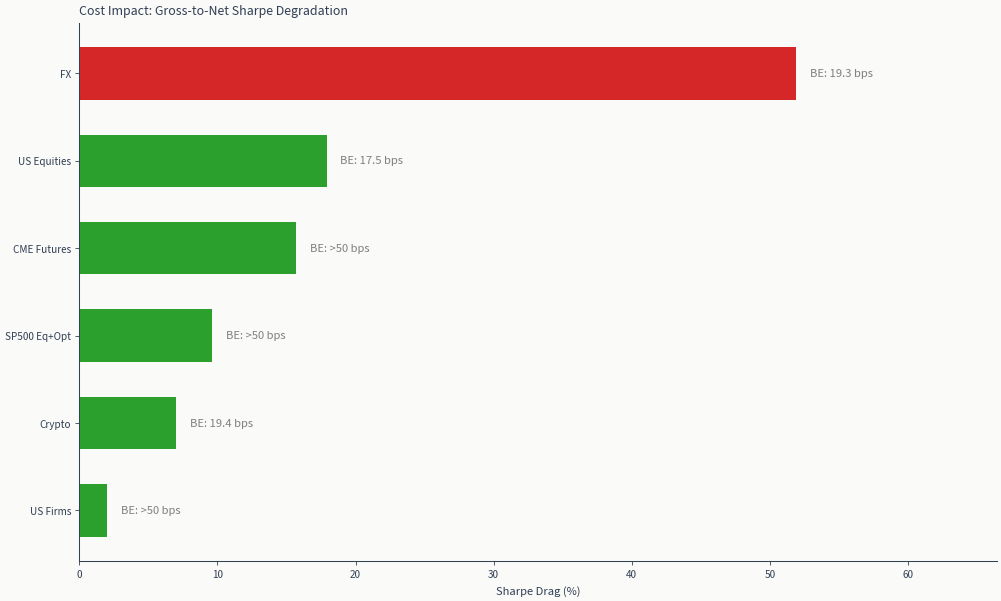

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#d62728" if drag > 50 else "#ff7f0e" if drag > 20 else "#2ca02c"
    for drag in summary["drag_pct"]
]

bars = ax.barh(
    range(len(summary)),
    summary["drag_pct"].to_list(),
    color=colors,
    edgecolor="none",
    height=0.6,
)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary["display_name"].to_list())
ax.set_xlabel("Sharpe Drag (%)")
ax.set_title("Cost Impact: Gross-to-Net Sharpe Degradation")
ax.invert_yaxis()

for bar, row in zip(bars, summary.iter_rows(named=True), strict=False):
    ax.annotate(
        f"BE: {'' if row['breakeven_observed'] else '>'}{row['breakeven_bps']:g} bps",
        xy=(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2),
        va="center",
        fontsize=9,
        color="gray",
    )
# Headroom so the breakeven annotation on the widest bar (FX) is not clipped.
ax.set_xlim(right=max(summary["drag_pct"]) * 1.28)

show_with_alt(
    fig,
    "Horizontal bars giving the percentage of gross Sharpe consumed by each case "
    "study's assumed cost, ordered by severity, each annotated with the cost at "
    "which that strategy breaks even.",
)

## Breakeven Cost Thresholds by Frequency

Breakeven cost is the maximum per-leg cost (in bps) at which the
deployed configuration still produces a positive Sharpe ratio. It is the cost
budget that the signal supports before becoming unprofitable.

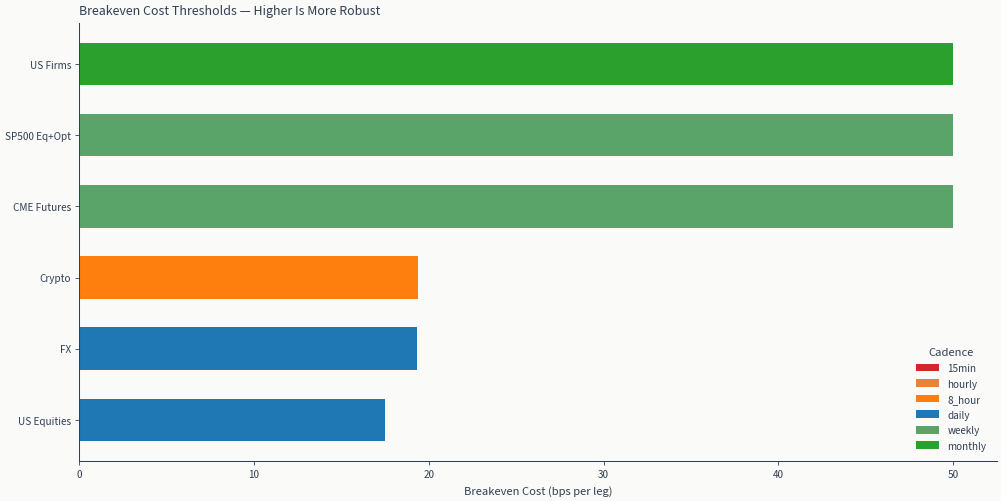

In [10]:
freq_order = list(CADENCE_PERIODS)
freq_colors = {
    "15min": "#d62728",
    "hourly": "#e8833a",
    "8_hour": "#ff7f0e",
    "daily": "#1f77b4",
    "weekly": "#5aa469",
    "monthly": "#2ca02c",
}

fig, ax = plt.subplots(figsize=(10, 5))

for i, row in enumerate(summary.sort("breakeven_bps").iter_rows(named=True)):
    color = freq_colors.get(row["cadence_period"], "gray")
    ax.barh(i, row["breakeven_bps"], color=color, height=0.6, edgecolor="none")

ax.set_yticks(range(len(summary)))
sorted_names = summary.sort("breakeven_bps")["display_name"].to_list()
ax.set_yticklabels(sorted_names)
ax.set_xlabel("Breakeven Cost (bps per leg)")
ax.set_title("Breakeven Cost Thresholds — Higher Is More Robust")

legend_handles = [Patch(facecolor=freq_colors[f], label=f) for f in freq_order if f in freq_colors]
ax.legend(handles=legend_handles, loc="lower right", title="Cadence")

show_with_alt(
    fig,
    "Horizontal bars of the breakeven per-leg cost for each case study, ordered "
    "from lowest to highest and coloured by rebalance cadence.",
)

## Cost Drag Curves

For each case study, plot Sharpe ratio as a function of per-leg
cost. This reveals the "cost cliff" — the point where a profitable
strategy becomes unprofitable.

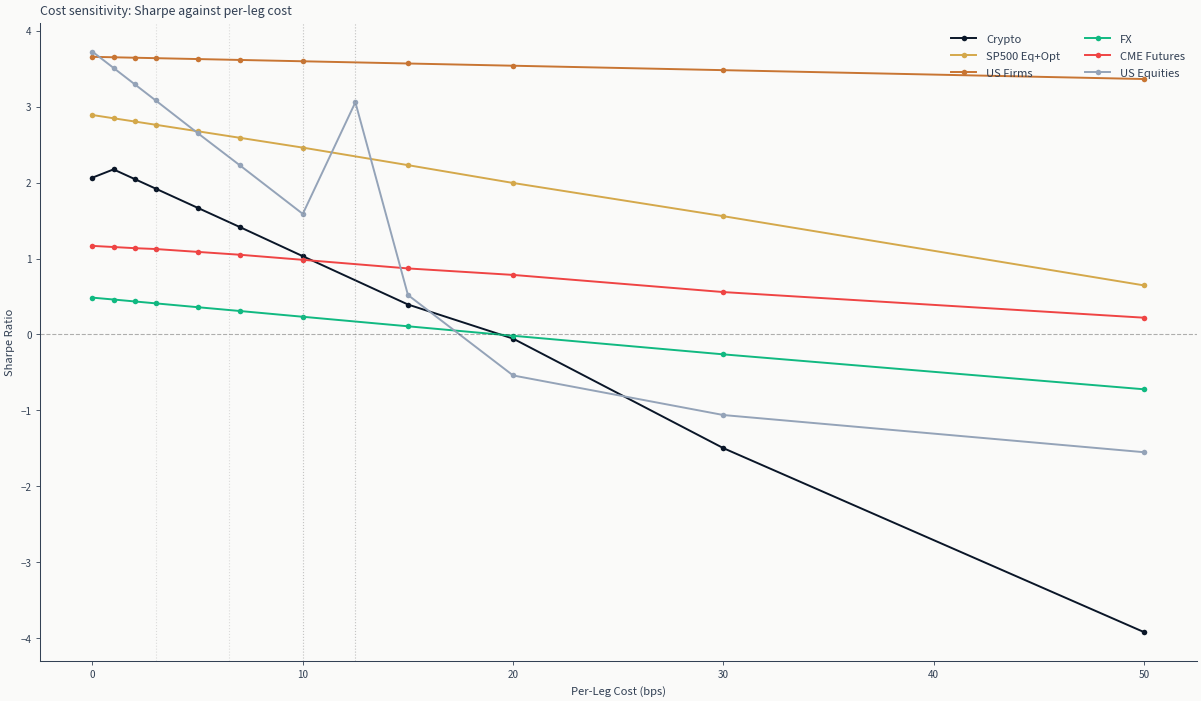

In [11]:
best_alloc_map = dict(
    zip(best_alloc["case_study"].to_list(), best_alloc["allocator"].to_list(), strict=False)
)

fig, ax = plt.subplots(figsize=(12, 7))

for cs_id in CS_LIST:
    alloc = best_alloc_map.get(cs_id)
    if alloc is None:
        continue

    cs_data = costs_df.filter(
        (pl.col("case_study") == cs_id) & (pl.col("allocator") == alloc)
    ).sort("cost_bps")

    if cs_data.is_empty():
        continue

    ax.plot(
        cs_data["cost_bps"].to_list(),
        cs_data["sharpe"].to_list(),
        marker="o",
        markersize=4,
        label=SHORT_NAMES.get(cs_id, cs_id),
    )

ax.axhline(y=0, color="black", linestyle="--", alpha=0.3, linewidth=0.8)
ax.set_xlabel("Per-Leg Cost (bps)")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Cost sensitivity: Sharpe against per-leg cost")
ax.legend(loc="upper right", fontsize=9, ncol=2)

# Mark each case study's assumed cost so the curve can be read at the point that
# matters rather than across the whole grid.
for cs_id in best_alloc_map:
    _c = ASSUMED_COST_BPS.get(cs_id)
    if _c is not None:
        ax.axvline(_c, color="gray", alpha=0.25, linewidth=0.8, linestyle=":")

show_with_alt(
    fig,
    "Line chart of Sharpe against per-leg cost in basis points, one line per "
    "case study over the swept grid, with a reference line at zero Sharpe and "
    "faint vertical lines marking each case study's assumed cost.",
)

## Cost Survival Classification

Each case study is classified by cost resilience: the ratio of its breakeven to
the per-leg cost it is assumed to pay. A higher ratio means more headroom once
realistic frictions are imposed. A ratio below one means the breakeven sits
under the assumed cost, so the strategy is already losing money at its own
assumption, and it is classified apart from a thin but positive margin.

The assumed cost is the one already in `summary`, read from each case study's
own setup rather than declared again here, so this table and the degradation
table above cannot disagree about what a case study is assumed to pay.

In [12]:
survival = summary.with_columns(
    cost_margin_bps=(pl.col("breakeven_bps") - pl.col("assumed_cost_bps")),
    cost_margin_ratio=(pl.col("breakeven_bps") / pl.col("assumed_cost_bps").clip(lower_bound=1)),
).with_columns(
    resilience=pl.when(pl.col("cost_margin_ratio") < 1)
    .then(pl.lit("does not survive"))
    .when(pl.col("cost_margin_ratio") >= 10)
    .then(pl.lit("very robust"))
    .when(pl.col("cost_margin_ratio") >= 3)
    .then(pl.lit("robust"))
    .when(pl.col("cost_margin_ratio") >= 1.5)
    .then(pl.lit("marginal"))
    .otherwise(pl.lit("fragile")),
)

print("=== Cost Survival Classification ===")
survival.select(
    "display_name",
    "cadence",
    "assumed_cost_bps",
    "net_sharpe",
    "breakeven_bps",
    "breakeven_observed",
    "cost_margin_ratio",
    "resilience",
)

=== Cost Survival Classification ===


display_name,cadence,assumed_cost_bps,net_sharpe,breakeven_bps,breakeven_observed,cost_margin_ratio,resilience
str,str,f64,f64,f64,bool,f64,str
"""FX""","""daily_ny_close""",10.0,0.233,19.3,true,1.93,"""marginal"""
"""US Equities""","""daily_close""",12.5,3.058,17.5,true,1.4,"""fragile"""
"""CME Futures""","""weekly_friday_close""",10.0,0.983,50.0,false,5.0,"""robust"""
"""SP500 Eq+Opt""","""weekly_friday_close""",6.5,2.612,50.0,false,7.692308,"""robust"""
"""Crypto""","""8_hour_funding_aligned""",3.0,1.921,19.4,true,6.466667,"""robust"""
"""US Firms""","""monthly_month_end""",12.5,3.583,50.0,false,4.0,"""robust"""


In [13]:
_res = survival.group_by("resilience").agg(cs=pl.col("display_name")).sort("resilience")
display(
    Markdown(
        "; ".join(
            f"**{r['resilience']}**: {', '.join(sorted(r['cs']))}"
            for r in _res.iter_rows(named=True)
        )
        + ". A ratio is only as good as the breakeven behind it, and where the "
        "sweep never crossed zero the breakeven is the grid ceiling rather than "
        "a crossing, so the ratio for those is a lower bound too."
    )
)

**fragile**: US Equities; **marginal**: FX; **robust**: CME Futures, Crypto, SP500 Eq+Opt, US Firms. A ratio is only as good as the breakeven behind it, and where the sweep never crossed zero the breakeven is the grid ceiling rather than a crossing, so the ratio for those is a lower bound too.

## S&P 500 Options: Spread Realism Caveat

The S&P 500 Options case study was validated using executable-label
backtesting, pricing straddle entries and exits at actual bid/ask quotes rather
than at an assumed bps cost. That case study has no selected configuration cost sweep, so it
does not appear in any table above.

It is described here for the structure of its cost problem rather than for its numbers, which
its own evaluation and §18.8 carry. A single-name option's dominant execution cost is the
bid-ask spread on the premium rather than a commission proportional to notional, so the cost
scales with how wide the quote is and not with how much is traded. That is why its evaluation
decomposes one prediction across three labels - priced at the mid and unhedged, delta-hedged
at the mid, and priced at the quotes a desk would actually get - which separates the signal's
contribution from the execution's, and why ranking on signal and spread jointly is a different
strategy from ranking on signal alone rather than a refinement of it.

A generic bps cost sweep misrepresents this case study for the same reason: it models a cost
that is proportional to notional. The teaching point is that strategy design has to optimize
for signal quality and execution cost together, because for this instrument the spread is what
the signal has to pay for.

## Cadence–Frequency–Cost Regime

The same IC translates to very different tradability depending on
rebalance cadence. A 15-minute strategy accumulates ~25× more turnover
per day than a daily strategy, and ~500× more than a monthly one.
This creates distinct cost regimes:

In [14]:
if not summary.is_empty():
    regime = summary.with_columns(
        turnover_mult=pl.col("cadence_period").replace_strict(
            TURNOVER_MULTIPLIER,
            default=1.0,
            return_dtype=pl.Float64,
        ),
    )

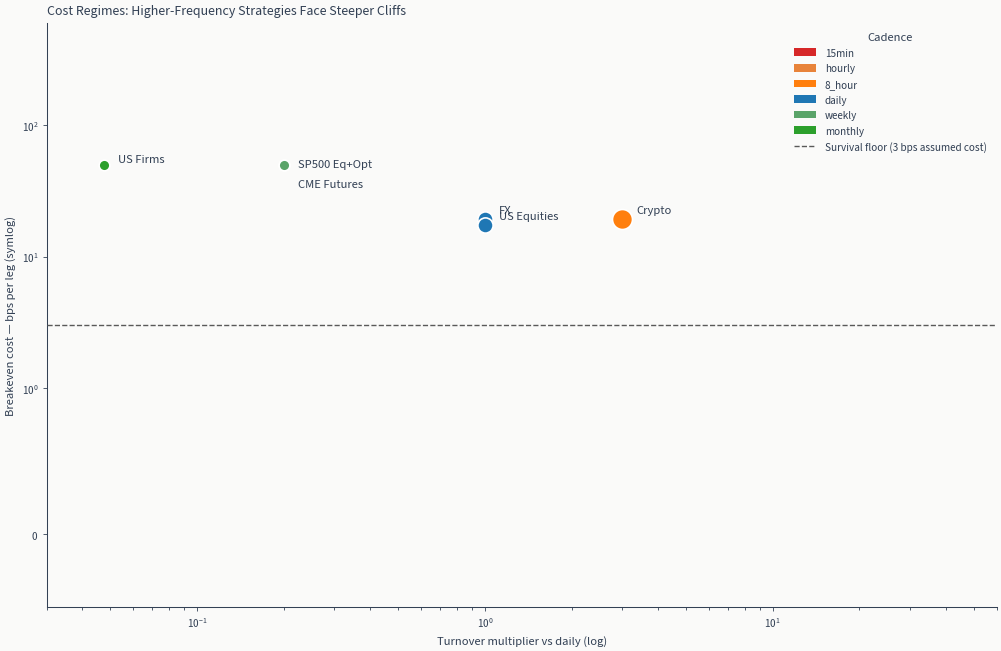

In [15]:
if not summary.is_empty():
    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Turnover-mult on x (varies 0.05→26×); breakeven on y. Both log so the
    # high-frequency cluster (NQ100/Crypto) and the monthly cluster
    # separate cleanly instead of stacking on a constant-x degenerate column.
    assumed_floor = max(float(summary["assumed_cost_bps"].min()), 0.5)

    # Monthly selected configurations share x (turnover ≈ 0.05) and pair up on y: ETFs and
    # US Firms at 50, CME and SP500 Eq+Opt at 30. Fan their labels vertically
    # so the two pairs stay legible despite the superimposed markers.
    label_offsets = {
        "NQ100": (10, 4),
        "Crypto": (10, 4),
        "FX": (10, 4),
        "US Equities": (10, 4),
        "ETFs": (10, 16),
        "US Firms": (10, 2),
        "SP500 Eq+Opt": (10, -2),
        "CME Futures": (10, -16),
        "SP500 Options": (10, 4),
    }

    for row in regime.iter_rows(named=True):
        color = freq_colors.get(row["cadence_period"], "gray")
        size = max(60, min(360, row["turnover_mult"] ** 0.5 * 120))
        ax.scatter(
            row["turnover_mult"],
            max(row["breakeven_bps"], 0.5),
            s=size,
            c=color,
            edgecolors="white",
            linewidth=1.2,
            zorder=5,
        )
        dx, dy = label_offsets.get(row["display_name"], (8, 8))
        ax.annotate(
            row["display_name"],
            (row["turnover_mult"], max(row["breakeven_bps"], 0.5)),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            zorder=6,
        )

    ax.axhline(
        assumed_floor,
        color="0.35",
        linestyle="--",
        linewidth=1.0,
        zorder=3,
        label=f"Survival floor ({assumed_floor:.0f} bps assumed cost)",
    )
    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlim(0.03, 60)
    ax.set_ylim(-0.5, 600)

    ax.set_xlabel("Turnover multiplier vs daily (log)")
    ax.set_ylabel("Breakeven cost — bps per leg (symlog)")
    ax.set_title("Cost Regimes: Higher-Frequency Strategies Face Steeper Cliffs")

    legend_handles = [
        Patch(facecolor=freq_colors[f], label=f) for f in freq_order if f in freq_colors
    ]
    ax.legend(
        handles=legend_handles + [ax.get_lines()[0]],
        loc="upper right",
        title="Cadence",
        framealpha=0.9,
    )

    show_with_alt(
        fig,
        "Log-log scatter of breakeven cost against assumed relative turnover, one "
        "marker per case study coloured by cadence, with a horizontal line at the "
        "lowest assumed cost in the panel.",
    )

In [16]:
_reg = regime.sort("turnover_mult", descending=True)
display(
    Markdown(
        "Marker x-position is assumed per-day turnover relative to a daily "
        "strategy, y is the cost at which net Sharpe crosses zero. The turnover "
        "multipliers are an assumption written into this notebook, not a "
        "measurement from the backtests: they say how often a book of a given "
        "cadence is expected to turn over, and the chart uses them to place the "
        "case studies rather than to test them.\n\n"
        + "; ".join(
            f"**{r['display_name']}** ({r['cadence']}), breakeven "
            f"{'' if r['breakeven_observed'] else 'at least '}"
            f"{r['breakeven_bps']:g} bps against an assumed "
            f"{r['assumed_cost_bps']:g}"
            for r in _reg.iter_rows(named=True)
        )
        + ".\n\nThe cadences present here span a narrow part of the range the "
        "chart is drawn for. The high-frequency corner is empty: NASDAQ-100's "
        "cost sweep ran a different strategy from its carrier, and the other "
        "sub-daily case studies have no cost sweep. Nothing here tests whether "
        "turnover or signal strength sets the breakeven, because the case "
        "studies that would separate them are the ones missing."
    )
)

Marker x-position is assumed per-day turnover relative to a daily strategy, y is the cost at which net Sharpe crosses zero. The turnover multipliers are an assumption written into this notebook, not a measurement from the backtests: they say how often a book of a given cadence is expected to turn over, and the chart uses them to place the case studies rather than to test them.

**Crypto** (8_hour_funding_aligned), breakeven 19.4 bps against an assumed 3; **FX** (daily_ny_close), breakeven 19.3 bps against an assumed 10; **US Equities** (daily_close), breakeven 17.5 bps against an assumed 12.5; **CME Futures** (weekly_friday_close), breakeven at least 50 bps against an assumed 10; **SP500 Eq+Opt** (weekly_friday_close), breakeven at least 50 bps against an assumed 6.5; **US Firms** (monthly_month_end), breakeven at least 50 bps against an assumed 12.5.

The cadences present here span a narrow part of the range the chart is drawn for. The high-frequency corner is empty: NASDAQ-100's cost sweep ran a different strategy from its carrier, and the other sub-daily case studies have no cost sweep. Nothing here tests whether turnover or signal strength sets the breakeven, because the case studies that would separate them are the ones missing.

## Key Takeaways

- **A cost sweep is only informative at the cost the strategy assumes.** The
  gross Sharpe and the Sharpe at the top of the grid are both easy to read off
  and neither is the number that decides whether the strategy is tradable. The
  assumed cost comes from the case study's own setup, and the tables above
  report the net Sharpe there.
- **Breakeven and assumed cost have to be compared, not reported side by
  side.** The ratio between them is the headroom, and a ratio below one means
  the strategy is already under water at its own assumption. The computed
  classification above says which case studies are where.
- **A breakeven above the top of the swept grid is not a breakeven.** Where the
  curve is still positive at the ceiling, the honest statement is that the
  crossing is somewhere above it, and the tables mark those rows rather than
  printing the ceiling as though it had been measured.
- **A basis-point grid does not model every cost structure.** Where the
  dominant cost is a wide bid-ask spread rather than a proportional fee, a bps
  sweep understates it, and the answer is an executable backtest against
  quotes. The S&P 500 Options section above is the worked case.

## Known Limitations

- Only case studies whose *carrier* has a cost sweep appear. The loaded count and
  one line per absent case study are printed at the top, so which check dropped a
  case study is read off the run rather than reconstructed by hand. A case study can
  hold cost-sensitivity backtests and still be absent, because the sweep has to sit
  on the deployed carrier's own training lineage and run the carrier's own strategy.
  Three are absent and each fails a different check. ETFs' carrier lineage carries no
  cost sweep at all. S&P 500 Options has eight cost rows on its carrier's lineage,
  all of them an `equal_weight_top_k` + `score_weighted` series rather than the
  carrier. NASDAQ-100 has 24 on its carrier's lineage, all of them `equal_weight_top_k`
  - the instrument its pass-1 ranking uses - while its carrier is a
  `slot_persistent_signal_exit` strategy. All three absences are properties of what
  was swept rather than of this chapter: a carrier with no cost sweep of its own has
  no cost curve to draw.
- The sweep applies one proportional per-leg cost to every trade. Real costs
  vary with size, with the instrument, and with the state of the book, and the
  spread realism section is where that assumption is checked rather than
  assumed.
- Net Sharpe at the assumed cost is interpolated between grid points; the
  bracketing points are in the table so the interpolation can be checked.
- The turnover multipliers used to place case studies on the cadence chart are
  stated assumptions about how often each cadence trades, not turnover measured
  from the backtests.
- Every Sharpe here is a validation-fold number for a configuration chosen on
  validation data, so the cost headroom inherits that selection.

**Next**: [`07_regime_risk`](07_regime_risk.ipynb) examines regime
robustness and risk overlays.